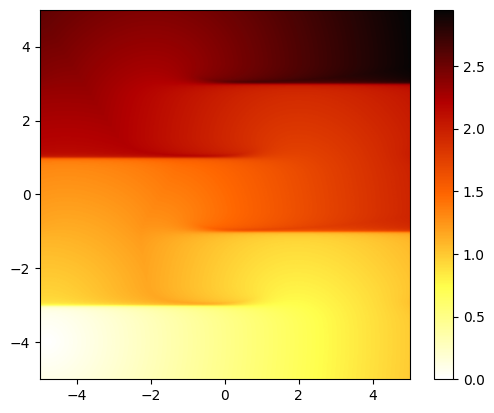

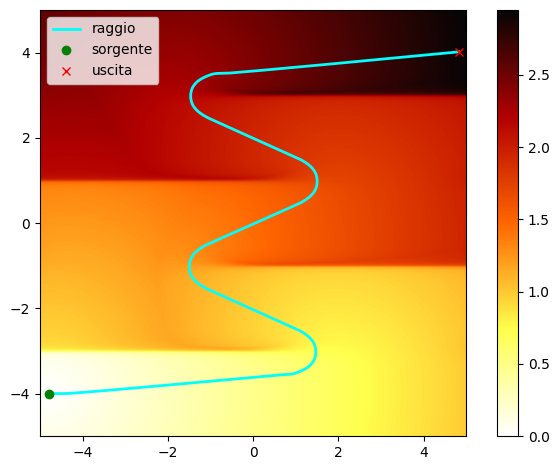

tempo raggio: 2.90575094683198


In [15]:
## VERSIONE FIM con raggio e interpolazione spline adattiva ##


#------------------  LIBRERIE --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import distance_transform_edt
# from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------
ny = 500
nx = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)

#punto iniziale (sorgente)
ix0 = 10
iy0 = 50

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

#------------------  CAMPO DI VELOCITA' (DUNE AL POSTO DEI MURI) ---------------

#------------------  CAMPO DI VELOCITA' (DUNE CON BORDI MORBIDI, SENZA SALTI) --

F_background = 10.0   # valore di F fuori dalle dune (ambiente "libero")
F_min = 0.1            # valore minimo di F al centro della duna
half_width = 25        # semi-larghezza (in righe) della zona di decadimento verticale
edge_smooth = 20        # larghezza (in colonne) della transizione morbida ai bordi dell'apertura

F = F_background * np.ones(X.shape)

def apply_dune(F, center_row, aperture_start, aperture_end,
                half_width, F_min, edge_smooth, F_background):
    """
    Crea una 'duna' larga attorno a center_row, con decadimento dolce sia
    verticalmente (lungo le righe) sia orizzontalmente ai bordi dell'apertura.
    Il profilo converge sempre a F_background ai bordi della fascia, in modo
    da non introdurre discontinuità rispetto al valore di sfondo.
    """
    nrows, ncols = F.shape
    rows = np.arange(nrows)
    cols = np.arange(ncols)

    # --- profilo verticale: F_background lontano dal centro, F_min al centro ---
    dist_row = np.abs(rows - center_row)
    profile_row = F_min + (F_background - F_min) * (1 - np.exp(-(dist_row**2) / (2 * (half_width/2.5)**2)))
    profile_row = np.clip(profile_row, F_min, F_background)

    # --- profilo orizzontale: F_background dentro l'apertura, transizione morbida ai bordi ---
    aperture_center = (aperture_start + aperture_end) / 2
    aperture_half_width = (aperture_end - aperture_start) / 2

    dist_from_center_col = np.abs(cols - aperture_center)
    gate = 1 / (1 + np.exp((dist_from_center_col - aperture_half_width) / edge_smooth))

    # --- combina i due profili sulla sotto-regione della duna ---
    row_mask = dist_row <= half_width
    for r in rows[row_mask]:
        # gate=1 (dentro apertura)      -> F = F_background
        # gate=0 (nella duna piena)     -> F = profile_row[r]
        # transizione morbida in mezzo
        F[r, :] = gate * F_background + (1 - gate) * profile_row[r]

    return F

# prima "duna" (centrata sulla vecchia riga 100, apertura a sinistra: colonne 349-498)
F = apply_dune(F, center_row=99,  aperture_start=349, aperture_end=498,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)
# seconda "duna" (centrata sulla vecchia riga 200, apertura a destra: colonne 1-150)
F = apply_dune(F, center_row=199, aperture_start=1,   aperture_end=150,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)
# terza "duna" (centrata sulla vecchia riga 300, apertura a sinistra: colonne 349-498)
F = apply_dune(F, center_row=299, aperture_start=349, aperture_end=498,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)
# quarta "duna" (centrata sulla vecchia riga 400, apertura a destra: colonne 1-150)
F = apply_dune(F, center_row=399, aperture_start=1,   aperture_end=150,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)

wall_mask = np.isinf(F)   # sarà tutto False, lasciato per compatibilità col resto del codice

# ==============================================================================
# CALCOLO FIM
# ==============================================================================

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

def Godunov_update(T, F, row, col):
  left  = np.where(col - 1 >= 0,      T[row, np.clip(col - 1, 0, nCols - 1)], np.inf)
  right = np.where(col + 1 < nCols,   T[row, np.clip(col + 1, 0, nCols - 1)], np.inf)
  down  = np.where(row - 1 >= 0,      T[np.clip(row - 1, 0, nRows - 1), col], np.inf)
  up    = np.where(row + 1 < nRows,   T[np.clip(row + 1, 0, nRows - 1), col], np.inf)

  Txmin = np.minimum(left, right)
  Tymin = np.minimum(down, up)

  a = np.minimum(Txmin, Tymin)
  b = np.maximum(Txmin, Tymin)

  f = F[row, col]
  rhs = h / f

  cond = (b - a) < rhs
  disc = 2 * rhs**2 - (a - b)**2
  disc = np.maximum(disc, 0)

  u_quad = (a + b + np.sqrt(disc)) / 2
  u_lin = a + rhs

  u = np.where(cond, u_quad, u_lin)

  return u


def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q

        converged_cond = np.abs(p - q) < 1e-6
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)

# Plot campo iconale
fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)


# ==============================================================================
# CALCOLO RAGGI CON INTERPOLAZIONE SPLINE ADATTIVA
# ==============================================================================

#------------------  CALCOLO DEI POLINOMI CUBICI HERMITIANI --------------------

def hermite_basis(s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2
    return h00, h10, h01, h11

def hermite_basis_deriv(s):
    h00p = 6*s**2 - 6*s
    h10p = 3*s**2 - 4*s + 1
    h01p = -6*s**2 + 6*s
    h11p = 3*s**2 - 2*s
    return h00p, h10p, h01p, h11p

#------------------  INTERPOLAZIONE HERMITIANA ---------------------------------

#controlla se i punti all'estrama dx-sx sono oltre un muro, in caso lo fossero
#non avrebbero significato, li scarta e ricorre alla forward/backward bi-sided
def hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=False, wall_p2=False):
    if wall_m1:
        m0 = (f_1 - f_0) / h          # forward difference
    else:
        m0 = (f_1 - f_m1) / (2*h)     # differenza centrata

    if wall_p2:
        m1 = (f_1 - f_0) / h          # backward difference
    else:
        m1 = (f_2 - f_0) / (2*h)      # differenza centrata

    h00, h10, h01, h11 = hermite_basis(s)
    val = h00*f_0 + h10*h*m0 + h01*f_1 + h11*h*m1

    h00p, h10p, h01p, h11p = hermite_basis_deriv(s)
    dval_ds = h00p*f_0 + h10p*h*m0 + h01p*f_1 + h11p*h*m1
    dval_dx = dval_ds / h

    return val, dval_dx

#controlla se i punti subito a dx-sx sono un muro, in caso lo fossero esegue
#la forward/backward one-sided
def hermite_1d_or_fallback(f_m1, f_0, f_1, f_2, s, h,
                            wall_m1=False, wall_p2=False,
                            wall_0=False, wall_1=False):
    if wall_0 and wall_1: #entrambi muro, valore non significativo
        return 0.5*(f_0+f_1), 0.0

    if wall_1 and not wall_0: #muro a dx, uso backward
        deriv = (f_0 - f_m1) / h if not wall_m1 else 0.0
        return f_0, deriv

    if wall_0 and not wall_1: #muro a sx, uso forward
        deriv = (f_2 - f_1) / h if not wall_p2 else 0.0
        return f_1, deriv

    #se è libero chiamo hermite
    return hermite_1d(f_m1, f_0, f_1, f_2, s, h, wall_m1=wall_m1, wall_p2=wall_p2)

#------------------  UTILITY FUNCTION ------------------------------------------

#ulteriore guard che serve a clippare gli indici che escono dai bordi
def clamp_index(j, n):
    return min(max(j, 1), n - 3)

#serve a restituire true se il punto (row,col) è un muro o è fuori dai bordi ed
#è utilizzata dalle funzioni hermitiane per controllare dove hanno il muro
def is_wall_rc(row, col, wall_mask):
    nrows, ncols = wall_mask.shape
    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return True
    return bool(wall_mask[row, col])

def is_wall_at(pt, F, x, y):
    col = np.clip(np.searchsorted(x, pt[0])- 1 , 0, F.shape[1] - 1)
    row = np.clip(np.searchsorted(y, pt[1]) - 1 , 0, F.shape[0] - 1)
    return np.isinf(F[row, col])

#------------------  INTERPOLAZIONE SPLINE -------------------------------------

#restituisce le dT/dx dT/dy interpolate tramite spline
def bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy):
    px, py = pt
    nrows, ncols = T_field.shape

    jx = int(np.floor((px - x[0]) / dx))
    jy = int(np.floor((py - y[0]) / dy))

    jx = clamp_index(jx, ncols)
    jy = clamp_index(jy, nrows)

    sx = (px - x[jx]) / dx
    sy = (py - y[jy]) / dy

    # passo 1: interpola sui 4 nodi lungo x ottenendo T(xq, yk) e dT(xq,yk)/dx
    # per le k = {1..4} colonne di y.
    g_val = np.empty(4)
    g_dx  = np.empty(4)
    for k, ry in enumerate((-1, 0, 1, 2)):
        row = jy + ry
        f_m1 = T_field[row, jx - 1] if jx - 1 >= 0 else T_field[row, jx]
        f_0  = T_field[row, jx]
        f_1  = T_field[row, jx + 1]
        f_2  = T_field[row, jx + 2] if jx + 2 < ncols else T_field[row, jx + 1]

        wall_left  = is_wall_rc(row, jx - 1, wall_mask)
        wall_right = is_wall_rc(row, jx + 2, wall_mask)
        wall_0     = is_wall_rc(row, jx, wall_mask)
        wall_1     = is_wall_rc(row, jx + 1, wall_mask)

        g_val[k], g_dx[k] = hermite_1d_or_fallback(
            f_m1, f_0, f_1, f_2, sx, dx,
            wall_m1=wall_left, wall_p2=wall_right,
            wall_0=wall_0, wall_1=wall_1)

    # passo 2: interpola sui 4 nodi lungo y in modo da calcolare e correggere le
    # derivate rispetto al punto fisico xq, ottenendo finalemente dT(xq,yq)/dx e
    # dT(xq,yq)/dy
    wall_down = is_wall_rc(jy - 1, jx, wall_mask) or is_wall_rc(jy - 1, jx + 1, wall_mask)
    wall_up   = is_wall_rc(jy + 2, jx, wall_mask) or is_wall_rc(jy + 2, jx + 1, wall_mask)
    wall_0y   = is_wall_rc(jy, jx, wall_mask) or is_wall_rc(jy, jx + 1, wall_mask)
    wall_1y   = is_wall_rc(jy + 1, jx, wall_mask) or is_wall_rc(jy + 1, jx + 1, wall_mask)

    _, dT_dy = hermite_1d_or_fallback(g_val[0], g_val[1], g_val[2], g_val[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)
    dT_dx, _ = hermite_1d_or_fallback(g_dx[0], g_dx[1], g_dx[2], g_dx[3], sy, dy,
                                       wall_m1=wall_down, wall_p2=wall_up,
                                       wall_0=wall_0y, wall_1=wall_1y)

    return dT_dx, dT_dy

#------------------  NORMALIZZAZIONE DEL GRADIENTE -----------------------------

def grad_at_local(pt, T_field, wall_mask, x, y, dx, dy):
    gx, gy = bicubic_local_grad(pt, T_field, wall_mask, x, y, dx, dy)
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    norm = np.sqrt(gx**2 + gy**2)
    if norm < 1e-12:
        return np.array([0.0, 0.0])
    scale = 1.0 / norm   # forza |grad T| = 1 (coerente con F=1 fuori dai muri)
    return np.array([gx * scale, gy * scale])

#------------------  RUNGE-KUTTA 4°ORDINE --------------------------------------

def trace_ray_rk4(start_pt, T_field, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy):
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-10:
            break

        k1 = -grad_at_local(pt, T_field, wall_mask, x, y, dx, dy)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at_local(pt + 0.5*ds*k1, T_field, wall_mask, x, y, dx, dy)
        k3 = -grad_at_local(pt + 0.5*ds*k2, T_field, wall_mask, x, y, dx, dy)
        k4 = -grad_at_local(pt + ds*k3, T_field, wall_mask, x, y, dx, dy)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        step_ds = ds
        pt_new = pt + step_ds * dpt
        n_tries = 0
        while is_wall_at(pt_new, F, x, y) and n_tries < 8:
            step_ds *= 0.5
            pt_new = pt + step_ds * dpt
            n_tries += 1

        ray.append(pt_new.copy())

        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CHIAMATA FINALE -------------------------------------------

source_pt = (x[ix0], y[iy0])  #punto sorgente
exit_pt = (x[490], y[450])  #punto finale

ds = dx/2   #passo di discretizzazione di rk4
max_steps = 40000

ray = trace_ray_rk4(exit_pt, T_final, wall_mask, source_pt, ds, max_steps, F, x, y, dx, dy)

#------------------  PLOT RAGGIO -----------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

def tempo_lungo_raggio(ray, F, x, y):
    """Integra il tempo di percorrenza sommando dl/F per ogni segmento del raggio."""
    tempo_tot = 0.0
    for i in range(len(ray) - 1):
        p0, p1 = ray[i], ray[i+1]
        dl = np.linalg.norm(p1 - p0)          # lunghezza del segmento
        mid = (p0 + p1) / 2                   # punto medio, per campionare F
        col = np.clip(np.searchsorted(x, mid[0]) - 1, 0, F.shape[1]-1)
        row = np.clip(np.searchsorted(y, mid[1]) - 1, 0, F.shape[0]-1)
        f_local = F[row, col]
        if np.isinf(f_local):
            f_local = 1e-6   # workaround: evita divisione per inf se il segmento tocca un muro
        tempo_tot += dl / f_local
    return tempo_tot

tempo_ray_spline = tempo_lungo_raggio(ray, F, x, y)
print("tempo raggio:", tempo_ray_spline)

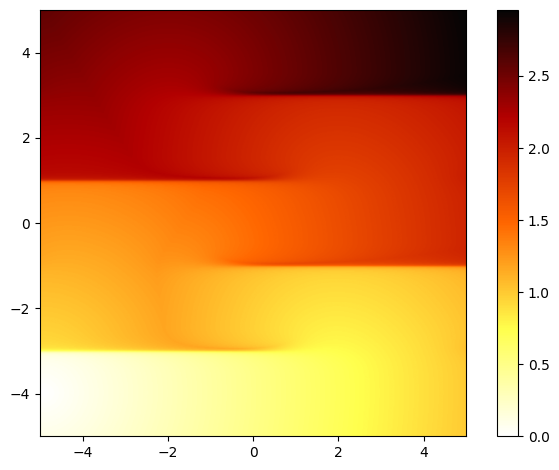

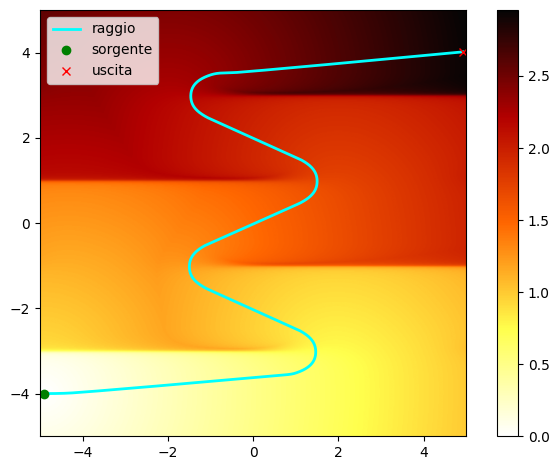

tempo raggio: 2.924619017322117


In [12]:
## VERSIONE FIM con raggio##

import numpy as np
import matplotlib.pyplot as plt

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#discretizzazione del dominio

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 50

#ix0 = 2000
#iy0 = 2000

#------------------  CAMPO DI VELOCITA' (DUNE AL POSTO DEI MURI) ---------------
#------------------  CAMPO DI VELOCITA' (DUNE CON BORDI MORBIDI, SENZA SALTI) --

F_background = 10.0   # valore di F fuori dalle dune (ambiente "libero")
F_min = 0.1            # valore minimo di F al centro della duna
half_width = 25        # semi-larghezza (in righe) della zona di decadimento verticale
edge_smooth = 20        # larghezza (in colonne) della transizione morbida ai bordi dell'apertura

F = F_background * np.ones(X.shape)

def apply_dune(F, center_row, aperture_start, aperture_end,
                half_width, F_min, edge_smooth, F_background):
    """
    Crea una 'duna' larga attorno a center_row, con decadimento dolce sia
    verticalmente (lungo le righe) sia orizzontalmente ai bordi dell'apertura.
    Il profilo converge sempre a F_background ai bordi della fascia, in modo
    da non introdurre discontinuità rispetto al valore di sfondo.
    """
    nrows, ncols = F.shape
    rows = np.arange(nrows)
    cols = np.arange(ncols)

    # --- profilo verticale: F_background lontano dal centro, F_min al centro ---
    dist_row = np.abs(rows - center_row)
    profile_row = F_min + (F_background - F_min) * (1 - np.exp(-(dist_row**2) / (2 * (half_width/2.5)**2)))
    profile_row = np.clip(profile_row, F_min, F_background)

    # --- profilo orizzontale: F_background dentro l'apertura, transizione morbida ai bordi ---
    aperture_center = (aperture_start + aperture_end) / 2
    aperture_half_width = (aperture_end - aperture_start) / 2

    dist_from_center_col = np.abs(cols - aperture_center)
    gate = 1 / (1 + np.exp((dist_from_center_col - aperture_half_width) / edge_smooth))

    # --- combina i due profili sulla sotto-regione della duna ---
    row_mask = dist_row <= half_width
    for r in rows[row_mask]:
        # gate=1 (dentro apertura)      -> F = F_background
        # gate=0 (nella duna piena)     -> F = profile_row[r]
        # transizione morbida in mezzo
        F[r, :] = gate * F_background + (1 - gate) * profile_row[r]

    return F

# prima "duna" (centrata sulla vecchia riga 100, apertura a sinistra: colonne 349-498)
F = apply_dune(F, center_row=99,  aperture_start=349, aperture_end=498,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)
# seconda "duna" (centrata sulla vecchia riga 200, apertura a destra: colonne 1-150)
F = apply_dune(F, center_row=199, aperture_start=1,   aperture_end=150,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)
# terza "duna" (centrata sulla vecchia riga 300, apertura a sinistra: colonne 349-498)
F = apply_dune(F, center_row=299, aperture_start=349, aperture_end=498,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)
# quarta "duna" (centrata sulla vecchia riga 400, apertura a destra: colonne 1-150)
F = apply_dune(F, center_row=399, aperture_start=1,   aperture_end=150,
               half_width=half_width, F_min=F_min, edge_smooth=edge_smooth, F_background=F_background)

wall_mask = np.isinf(F)   # sarà tutto False, lasciato per compatibilità col resto del codice
T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0


active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

def Godunov_update(T, F, row, col):
  left  = np.where(col - 1 >= 0,      T[row, np.clip(col - 1, 0, nCols - 1)], np.inf)
  right = np.where(col + 1 < nCols,   T[row, np.clip(col + 1, 0, nCols - 1)], np.inf)
  down  = np.where(row - 1 >= 0,      T[np.clip(row - 1, 0, nRows - 1), col], np.inf)
  up    = np.where(row + 1 < nRows,   T[np.clip(row + 1, 0, nRows - 1), col], np.inf)

  Txmin = np.minimum(left, right)
  Tymin = np.minimum(down,up)

  a = np.minimum(Txmin, Tymin)
  b = np.maximum(Txmin, Tymin)

  f = F[row,col]
  rhs = h / f

  cond = (b - a) < rhs
  disc = 2 * rhs**2 - (a - b)**2
  disc = np.maximum(disc, 0)

  u_quad = (a + b + np.sqrt(disc)) / 2
  u_lin = a + rhs

  u = np.where(cond, u_quad, u_lin)

  return u


def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)

# Plot
fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()


# ----------------------------------RAGGI---------------------------------------


def Gradient_FD(T_final, F, dx, dy):
    wall_mask = np.isinf(F)
    nRows, nCols = T_final.shape

    Tx = np.zeros_like(T_final)
    Ty = np.zeros_like(T_final)

    # --- Derivata rispetto a x (colonne) ---
    valid = ~wall_mask

    left_ok  = np.zeros_like(valid)
    right_ok = np.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]   # vicino a sinistra è valido
    right_ok[:, :-1] = valid[:, 1:]   # vicino a destra è valido

    T_left  = np.full_like(T_final, np.nan)
    T_right = np.full_like(T_final, np.nan)
    T_left[:, 1:]  = T_final[:, :-1]
    T_right[:, :-1] = T_final[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok    # solo sinistra disponibile → backward diff
    only_right_x = right_ok & ~left_ok    # solo destra disponibile → forward diff

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_final[only_right_x]) / dx
    Tx[only_left_x]  = (T_final[only_left_x] - T_left[only_left_x]) / dx
    # entrambi i vicini muro (o cella stessa muro) → Tx resta 0

    # --- Derivata rispetto a y (righe) ---
    down_ok = np.zeros_like(valid)
    up_ok   = np.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]    # vicino sotto è valido
    up_ok[:-1, :]  = valid[1:, :]     # vicino sopra è valido

    T_down = np.full_like(T_final, np.nan)
    T_up   = np.full_like(T_final, np.nan)
    T_down[1:, :] = T_final[:-1, :]
    T_up[:-1, :]  = T_final[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_final[only_up_y]) / dy
    Ty[only_down_y] = (T_final[only_down_y] - T_down[only_down_y]) / dy

    # --- Rinormalizzazione secondo l'eikonale: |grad T| = 1/F ---
    grad_norm = np.sqrt(Tx**2 + Ty**2)
    scale = np.zeros_like(grad_norm)
    finite_F = np.isfinite(F) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F[finite_F] * grad_norm[finite_F])

    Tx = np.where(finite_F, Tx * scale, 0.0)
    Ty = np.where(finite_F, Ty * scale, 0.0)

    # azzera esplicitamente le celle muro
    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty

Tx = np.zeros_like(T_final)
Ty = np.zeros_like(T_final)

Tx, Ty = Gradient_FD(T_final, F, dx, dy)


def fill_wall_nans(field, wall_mask):
    """Sostituisce i valori nelle celle muro con quelli della cella valida più vicina."""
    # indici della cella valida più vicina per ogni punto della griglia
    idx = distance_transform_edt(wall_mask, return_distances=False, return_indices=True)
    return field[tuple(idx)]


wall_mask = np.isinf(F)

Tx_filled = fill_wall_nans(Tx, wall_mask)
Ty_filled = fill_wall_nans(Ty, wall_mask)

Tx_interp = RegularGridInterpolator((y, x), Tx_filled, method='linear',
                                     bounds_error=False, fill_value=None)
Ty_interp = RegularGridInterpolator((y, x), Ty_filled, method='linear',
                                     bounds_error=False, fill_value=None)



def grad_at(pt, Tx_interp, Ty_interp):
    """pt = (px, py) in coordinate cartesiane."""
    px, py = pt
    point = np.array([[py, px]])  # RegularGridInterpolator vuole shape (n_points, n_dims)
    gx = Tx_interp(point)[0]
    gy = Ty_interp(point)[0]
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    return np.array([gx, gy])


def trace_ray_rk4(start_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps):
    """
    Integra all'indietro seguendo -grad(T) a partire da start_pt (uscita)
    fino ad avvicinarsi a source_pt (sorgente).
    """
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
          break

        k1 = -grad_at(pt, Tx_interp, Ty_interp)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at(pt + 0.5*ds*k1, Tx_interp, Ty_interp)
        k3 = -grad_at(pt + 0.5*ds*k2, Tx_interp, Ty_interp)
        k4 = -grad_at(pt + ds*k3, Tx_interp, Ty_interp)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0
        pt_new = pt + ds * dpt

        ray.append(pt_new.copy())

        # criterio di arresto: raggio arrivato vicino alla sorgente
        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        # criterio di stagnazione (raggio bloccato, es. contro un muro)
        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)


# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])

# punto d'uscita in alto a destra del dominio
exit_pt = (x[495], y[450])

ds = dx  # passo di integrazione
max_steps = 20000

ray = trace_ray_rk4(exit_pt, Tx_interp, Ty_interp, source_pt, ds, max_steps)



fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

def tempo_lungo_raggio(ray, F, x, y):
    """Integra il tempo di percorrenza sommando dl/F per ogni segmento del raggio."""
    tempo_tot = 0.0
    for i in range(len(ray) - 1):
        p0, p1 = ray[i], ray[i+1]
        dl = np.linalg.norm(p1 - p0)          # lunghezza del segmento
        mid = (p0 + p1) / 2                   # punto medio, per campionare F
        col = np.clip(np.searchsorted(x, mid[0]) - 1, 0, F.shape[1]-1)
        row = np.clip(np.searchsorted(y, mid[1]) - 1, 0, F.shape[0]-1)
        f_local = F[row, col]
        if np.isinf(f_local):
            f_local = 1e-6   # workaround: evita divisione per inf se il segmento tocca un muro
        tempo_tot += dl / f_local
    return tempo_tot

tempo_ray_spline = tempo_lungo_raggio(ray, F, x, y)
print("tempo raggio:", tempo_ray_spline)